In [57]:

import hbsir
import matplotlib
import numpy as np
import pandas as pd
import sns
import seaborn as sns

import statsmodels.formula.api as smf


In [58]:
import yaml


def extract_table_names(yaml_file_path):
    with open(yaml_file_path, 'r', encoding='utf-8') as file:
        schema = yaml.safe_load(file)

    table_names = set()

    # Extract top-level tables (direct keys)
    for key in schema.keys():
        if isinstance(schema[key], dict) and 'instructions' in schema[key]:
            table_names.add(key)

    # Extract tables from table_list sections
    for section in schema.values():
        if isinstance(section, dict) and 'table_list' in section:
            table_list = section['table_list']
            if isinstance(table_list, dict):
                for tables in table_list.values():
                    if isinstance(tables, list):
                        table_names.update(tables)
                    elif isinstance(tables, str):
                        table_names.add(tables)
            elif isinstance(table_list, list):
                table_names.update(table_list)

    # Remove None if present and sort alphabetically
    table_names.discard(None)
    return sorted(table_names)


# Usage example
yaml_file = r'.\schema.yaml'
tables = extract_table_names(yaml_file)
print(tables)

['Administrative_Divisions', 'Cash_Incomes', 'Equivalence_Scale', 'Expenditures', 'Imputed_Rent', 'Income_Breakdown', 'Members_Income_Breakdown', 'Members_Total_Income', 'NonCash_Incomes', 'NonCash_Incomes_Excluding_Imputed_Rent', 'Number_of_Members', 'Original_Expenditures', 'Original_Outlays', 'Outlays', 'Season', 'Total_Expenditure', 'Total_Income', 'Total_Outlay', 'Weight', '_long_other_income', 'census_month', 'cloth', 'communication', 'durable', 'education', 'employment_income', 'entertainment', 'external.hbsir_weights', 'food', 'furniture', 'home', 'hotel', 'house_specifications', 'household_information', 'investment', 'medical', 'members_properties', 'miscellaneous', 'old_rural_house_specifications', 'old_urban_house_specifications', 'other_income', 'private_employment_income', 'public_employment_income', 'self_employed_income', 'subsidy', 'tobacco', 'transportation']


In [74]:
import os

lyear = 1403
hbsir.setup("all", method="download_cleaned")
hbsir.setup(years=f"{lyear}", method="download_cleaned", download_source="mirror")
years = [lyear]
tables = extract_table_names(yaml_file)

for year in years:
    for t in tables:
        try:
            print("Loading year", year)
            table = hbsir.load_table(t, years=year)
            directory_path = rf'D:\regres project\csvs data\{t}\{year}'
            os.makedirs(directory_path, exist_ok=True)
            output = os.path.join(directory_path, f'{t}_{year}.csv')
            table.to_csv(output, index=False)
            print("Table", year, "done!")
        except Exception as e:
            print(f"Error processing year {year}: {e}")
            continue

Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to concatenate
Loading year 1403
Error processing year 1403: No objects to conc

In [7]:
def csvfind(tableName, year):
    path = "D:\\regres project\\csvs data\\" + tableName + "\\" + str(year) + "\\" + tableName + "_" + str(
        year) + ".csv"
    return pd.read_csv(path)

In [8]:
def get_total_income(year):
    a = csvfind("Total_Income", year)
    return a.groupby("ID")["Income"].sum().reset_index()

In [9]:
expenditures_95 = csvfind(tableName="Expenditures", year=1395)

In [10]:

expenditures_95 = hbsir.add_attribute(table=expenditures_95, name='Province', year_col="Year", id_col="ID")
expenditures_95 = hbsir.add_attribute(table=expenditures_95, name="Urban_Rural", year_col="Year", id_col="ID")
expenditures_95 = hbsir.add_attribute(table=expenditures_95, name="County", year_col="Year", id_col="ID")


In [11]:
members_properties_95 = csvfind(tableName="members_properties", year=1395)
employment_income_95 = csvfind("employment_income", 1395)

In [12]:
head_edu = members_properties_95[members_properties_95["Member_Number"] == 1][["ID", "Education_Level"]]
# hh_income = employment_income_95.groupby("ID")["Annual_Continuous_Income"].sum().reset_index()
hh_income = get_total_income(year=1395)
hh_income.rename(columns={"Income": "Household_Income"}, inplace=True)

In [13]:
merged = pd.merge(hh_income, head_edu, on="ID")
merged = merged.where(pd.notnull(merged), "None")
print(merged.head())


            ID  Household_Income Education_Level
0  10001000120        66920000.0            None
1  10001000123        96840000.0            None
2  10001000126       143460000.0            None
3  10001000129        38960000.0            None
4  10001000132       224920000.0            None


In [14]:
mean_income_by_edu = merged.groupby("Education_Level")["Household_Income"].mean().sort_values(ascending=False)
print(mean_income_by_edu)


Education_Level
Doctoral                9.434833e+08
Masters                 4.812501e+08
Bachelors               3.972277e+08
Short_Cycle_Tertiary    3.445846e+08
Pre_University          2.820993e+08
Lower_Secondary         2.216930e+08
Higher_Secondary        2.204085e+08
Primary                 2.110458e+08
Unofficial              1.897082e+08
None                    1.473819e+08
Name: Household_Income, dtype: float64


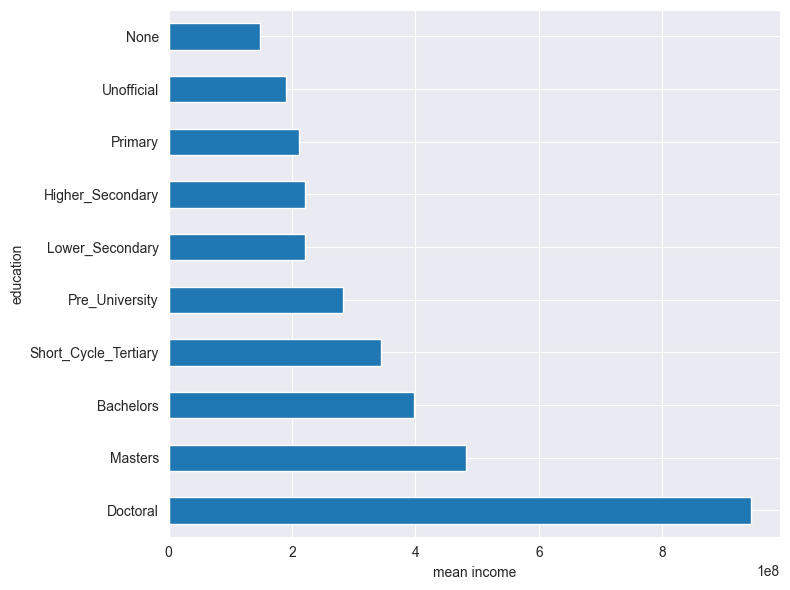

In [15]:
import matplotlib.pyplot as plt

mean_income_by_edu.plot(kind="barh", figsize=(8, 6))
plt.xlabel("mean income")
plt.ylabel("education")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.linear_model import LinearRegression


def regression_with_interactions_sklearn(df, independent_vars, target_var):
    # انتخاب داده‌ها
    X = df[independent_vars]
    y = df[target_var]

    # تبدیل متغیرهای رشته‌ای به عددی
    X = pd.get_dummies(X, drop_first=True)

    # ساخت متغیرهای تعاملی
    interaction_terms = []
    columns = list(X.columns)

    for var1, var2 in combinations(columns, 2):
        interaction_name = f'{var1}:{var2}'
        interaction_terms.append(X[var1] * X[var2])
        interaction_terms[-1].name = interaction_name

    # اضافه کردن متغیرهای تعاملی به X
    X = pd.concat([X] + interaction_terms, axis=1)

    # اضافه کردن یک ستون ثابت (intercept) برای مدل
    X['constant'] = 1

    # ساخت مدل رگرسیونی
    model = LinearRegression()

    # برازش مدل
    model.fit(X, y)

    # نمایش ضرایب
    coef_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
    return coef_df

# فرض کنید df دیتافریم شماست که شامل متغیرهای X1, X2, X3 و y است
# independent_vars = ['X1', 'X2', 'X3']
# # لیست ستون‌ها برای متغیرهای ورودی
# target_var = 'y'  # اسم ستون هدف
# df = pd.DataFrame()
# result = regression_with_interactions_sklearn(df, independent_vars, target_var)
# print(result)

In [17]:
import statsmodels.api as sm
from itertools import combinations


def regression_with_interactions(df, independent_vars, target_var):
    # انتخاب داده‌ها
    X = df[independent_vars]
    y = df[target_var]

    # تبدیل متغیرهای رشته‌ای به عددی
    X = pd.get_dummies(X, drop_first=True)

    # ساختن متغیرهای تعاملی
    interaction_terms = []
    columns = list(X.columns)

    for var1, var2 in combinations(columns, 2):
        interaction_name = f'{var1}_&_{var2}'
        interaction_terms.append(X[var1] * X[var2])
        interaction_terms[-1].name = interaction_name

    # اضافه کردن متغیرهای تعاملی
    X = pd.concat([X] + interaction_terms, axis=1)

    # افزودن ستون ثابت
    X = sm.add_constant(X)

    # برازش مدل
    model = sm.OLS(y, X).fit()

    return model

In [18]:
merged = pd.merge(expenditures_95, members_properties_95, on="ID")


In [19]:
table_1395 = expenditures_95
# table_1395 = hbsir.add_attribute(table=table_1395, name='Province',year_col="Year" ,id_col="ID")
# table_1395 = hbsir.add_attribute(table=table_1395, name="Urban_Rural",year_col="Year" ,id_col="ID")
# table_1395 = hbsir.add_attribute(table=table_1395, name="County",year_col="Year" ,id_col="ID")
hhinc_1395 = csvfind(tableName="employment_income", year=1395)
members_1395 = csvfind("members_properties", 1395)

C:\Users\Pc-Tech\AppData\Local\Temp\ipykernel_836\3727247502.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_income_1395 = df_1395.groupby("Education_Level")["Annual_Continuous_Income"].mean().reindex(valid_levels)


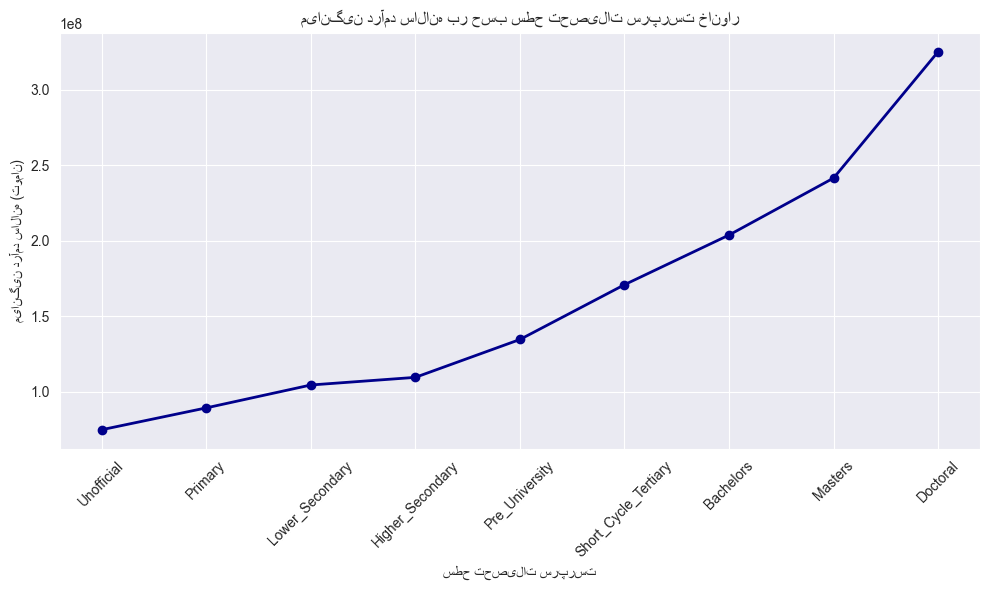

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# لیست مرتب‌شده سطح تحصیلات
valid_levels = [
    "Unofficial",
    "Primary",
    "Lower_Secondary",
    "Higher_Secondary",
    "Pre_University",
    "Short_Cycle_Tertiary",
    "Bachelors",
    "Masters",
    "Doctoral"
]

# فیلتر فقط سرپرست‌ها با سطح تحصیلات معتبر
df_1395 = members_1395[
    (members_1395["Member_Number"] == 1) & (members_1395["Education_Level"].isin(valid_levels))].copy()

# تبدیل به نوع مرتب Categorical
df_1395["Education_Level"] = pd.Categorical(df_1395["Education_Level"], categories=valid_levels, ordered=True)

# اضافه کردن درآمد سرپرست‌ها از hhinc
df_1395 = df_1395.merge(
    hhinc_1395[hhinc_1395["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
    on="ID",
    how="left"
)

# حذف ردیف‌هایی که درآمد ندارن
df_1395 = df_1395.dropna(subset=["Annual_Continuous_Income"])

# محاسبه میانگین درآمد برای هر سطح تحصیل
mean_income_1395 = df_1395.groupby("Education_Level")["Annual_Continuous_Income"].mean().reindex(valid_levels)

# 📈 رسم نمودار
plt.figure(figsize=(10, 6))
plt.plot(mean_income_1395.index, mean_income_1395.values, marker='o', color='darkblue', linewidth=2)
plt.xlabel("سطح تحصیلات سرپرست")
plt.ylabel("میانگین درآمد سالانه (تومان)")
plt.title("میانگین درآمد سالانه بر حسب سطح تحصیلات سرپرست خانوار")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [21]:
def uploadingData(year):
    table = csvfind("Expenditures", year=year)
    table = hbsir.add_attribute(table=table, name='Province', year_col="Year", id_col="ID")
    table = hbsir.add_attribute(table=table, name="Urban_Rural", year_col="Year", id_col="ID")
    table = hbsir.add_attribute(table=table, name="County", year_col="Year", id_col="ID")
    hhinc = csvfind("employment_income", year=year)
    members = csvfind("members_properties", year=year)
    return table, hhinc, members


def proccessData(members, hhinc):
    # ---------- پردازش ----------
    df = members[(members["Member_Number"] == 1) &
                 (members["Education_Level"].isin(valid_levels))].copy()
    df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)

    df = df.merge(
        hhinc[hhinc["Member_Number"] == 1][["ID", "Annual_Continuous_Income"]],
        on="ID", how="left"
    )
    return df


edu_map = {
    "Unofficial": 0,
    "Primary": 5,
    "Lower_Secondary": 8,
    "Higher_Secondary": 12,
    "Pre_University": 13,
    "Short_Cycle_Tertiary": 14,
    "Bachelors": 16,
    "Masters": 18,
    "Doctoral": 22
}

In [22]:
# tables=[]
# for year in range(1395, 1402):
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = proccessData(members, hhinc)
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         df = df.merge(urban_rural, on="ID", how="left")
#
#         df = df.dropna(subset=["Annual_Continuous_Income"])
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # ---------- مدل ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- نمودار ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [23]:
# import hbsir
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# import statsmodels.formula.api as smf
#
# valid_levels = [
#     "Unofficial", "Primary", "Lower_Secondary", "Higher_Secondary",
#     "Pre_University", "Short_Cycle_Tertiary", "Bachelors", "Masters", "Doctoral"
# ]
#
# edu_map = {
#     "Unofficial": 0, "Primary": 5, "Lower_Secondary": 8, "Higher_Secondary": 12,
#     "Pre_University": 13, "Short_Cycle_Tertiary": 14, "Bachelors": 16,
#     "Masters": 18, "Doctoral": 22
# }
#
# for year in range(1396, 1402):
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # --- بارگذاری داده‌ها ---
#         table, hhinc, members = uploadingData(year)
#         df = proccessData(members, hhinc)
#
#         # Add urban/rural
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         df = df.merge(urban_rural, on="ID", how="left")
#
#         # Remove rows without income
#         df = df.dropna(subset=["Annual_Continuous_Income"])
#
#         # Convert Urban_Rural to 0 and 1
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # --- Modeling ---
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#         #
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # --- Prediction data ---
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         # --- Plotting ---
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#
#         # Without interaction + actual points
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             # Regression line
#             subset_line = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset_line["Years_Edu"], subset_line["pred_no_inter"], color=color, label=label)
#
#             # Actual points
#             subset_points = df[df["Urban"] == u]
#             axes[0].scatter(subset_points["Years_Edu"], subset_points["Annual_Continuous_Income"],
#                             color=color, alpha=0.5, s=20)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         # With interaction + actual points
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset_line = plot_df[plot_df["Urban"] == u]
#             axes[1].plot(subset_line["Years_Edu"], subset_line["pred_inter"], color=color, label=label)
#
#             subset_points = df[df["Urban"] == u]
#             axes[1].scatter(subset_points["Years_Edu"], subset_points["Annual_Continuous_Income"],
#                             color=color, alpha=0.5, s=20)
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [24]:
# for year in range(1395, 1402):
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = proccessData(members, hhinc)
#
#         # Gender column: Assuming Gender column exists in members
#         # Male -> 1, Female -> 0
#         df["Gender_Binary"] = df["Sex"].apply(lambda x: 1 if str(x).lower() == "male" else 0)
#
#         # Remove rows without income or gender
#         df = df.dropna(subset=["Annual_Continuous_Income", "Gender_Binary"])
#
#         # ---------- Model ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Gender_Binary", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Gender_Binary", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#         #
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- Plot ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Gender_Binary": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for g, color, label in [(0, "purple", "Female"), (1, "green", "Male")]:
#             subset = plot_df[plot_df["Gender_Binary"] == g]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [25]:
# ## spouse income
# for year in range(1395, 1402):
#
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = members[(members["Relationship"] == "Spouse") &
#                      (members["Education_Level"].isin(valid_levels))].copy()
#         df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)
#         df = df.merge(
#             hhinc[["ID", "Annual_Continuous_Income"]],
#             on="ID", how="left"
#         )
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         df = df.merge(urban_rural, on="ID", how="left")
#
#         df = df.dropna(subset=["Annual_Continuous_Income"])
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # ---------- مدل ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- نمودار ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [26]:
# ## family income
# for year in range(1395, 1402):
#
#     print(f"\n=== Processing year {year} ===")
#     try:
#         # ---------- بارگذاری داده‌ها ----------
#         table, hhinc, members = uploadingData(year)
#         df = pd.merge(members, hhinc, on=["ID","Member_Number"], how="left")
#
#
#
#
#         df = members[(members["Education_Level"].isin(valid_levels))].copy()
#         df["Years_Edu"] = df["Education_Level"].map(edu_map).astype(float)
#
#         df = df.merge(
#             hhinc[["ID","Member_Number", "Annual_Continuous_Income"]],
#            on=["ID","Member_Number"], how="left"
#         )
#         df = df.dropna(subset=["Annual_Continuous_Income" , "Education_Level"])
#
#         result = df.groupby('ID').agg({
#         'Annual_Continuous_Income': 'sum' ,"Years_Edu":"max"}).reset_index()
#
#         urban_rural = table[["ID", "Urban_Rural"]].drop_duplicates()
#         result = result.merge(urban_rural, on="ID", how="left")
#         df = result
#         df["Urban"] = df["Urban_Rural"].apply(lambda x: 1 if str(x).lower() == "urban" else 0)
#
#         # ---------- مدل ----------
#         model_no_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu + Urban", data=df).fit()
#         model_inter = smf.ols("Annual_Continuous_Income ~ Years_Edu * Urban", data=df).fit()
#
#         # print("\n---- Model without interaction ----")
#         # print(model_no_inter.summary())
#
#         # print("\n---- Model with interaction ----")
#         # print(model_inter.summary())
#
#         # ---------- نمودار ----------
#         years_range = np.linspace(df["Years_Edu"].min(), df["Years_Edu"].max(), 100)
#         plot_df = pd.DataFrame({
#             "Years_Edu": np.tile(years_range, 2),
#             "Urban": np.repeat([0, 1], len(years_range))
#         })
#         plot_df["pred_no_inter"] = model_no_inter.predict(plot_df)
#         plot_df["pred_inter"] = model_inter.predict(plot_df)
#
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#         for u, color, label in [(0, "black", "Rural"), (1, "red", "Urban")]:
#             subset = plot_df[plot_df["Urban"] == u]
#             axes[0].plot(subset["Years_Edu"], subset["pred_no_inter"], color=color, label=label)
#             axes[1].plot(subset["Years_Edu"], subset["pred_inter"], color=color, label=label)
#
#         axes[0].set_title(f"No interaction - {year}")
#         axes[0].set_xlabel("Years of Education")
#         axes[0].set_ylabel("Predicted Income")
#         axes[0].legend()
#
#         axes[1].set_title(f"With interaction - {year}")
#         axes[1].set_xlabel("Years of Education")
#         axes[1].legend()
#
#         plt.tight_layout()
#         plt.show()
#
#     except Exception as e:
#         print(f"⚠ Error processing year {year}: {e}")
#         continue

In [27]:
# #for year in range(1395, 1402):
# year = 1402
# print(f"---------------{year}---------------")
# food = csvfind("food", year)
# Tobacco = csvfind("tobacco", year)
# Cloth = csvfind("cloth", year)
# Home = csvfind("home", year)
# Furniture = csvfind("furniture", year)
# Medical = csvfind("medical", year)
# Transportation = csvfind("transportation", year)
# Communication = csvfind("communication", year)
# Entertainment = csvfind("entertainment", year)
# # Education = csvfind("education",year)
# Hotel = csvfind("hotel", year)
# Miscellaneous = csvfind("miscellaneous", year)
# Durable = csvfind("durable", year)
# Investment = csvfind("investment", year)
# employment_income = csvfind("employment_income", year)
# tables = [food, Tobacco, Cloth, Home, Furniture, Medical, Transportation, Communication, Entertainment, Hotel,
#           Miscellaneous, Durable, Investment]
# employment_income = get_total_income(year)
# # for table in tables:
# for table in tables:
#     try:
#         result = employment_income
#         result.rename(columns={'Income': 'Monthly_Income'}, inplace=True)
#         result['Monthly_Income'] = result['Monthly_Income']
#         name = table['Table_Name'].loc[0]
#         table['Expenditure'] = table['Expenditure'].fillna(0)
#         table = table.groupby('ID').agg({'Expenditure': 'sum'}).reset_index()
#         result = pd.merge(result, table, on="ID")
#         result_main = result
#         result_main = result_main[result_main['Expenditure'] < result_main['Monthly_Income']]
#         result['Expenditure'] = result['Expenditure'] / result['Monthly_Income']
#         result['Expenditure'] = result['Expenditure'] * 100
#         result = result[result['Expenditure'] < 100]
#
#     except Exception as e:
#         print(f"<UNK> Error processing table {name}: {e}")
#     print(f"---------------{name}-----------------")
#     # for table in tables:
#     result = result.groupby('Monthly_Income').agg({
#         'Expenditure': 'mean'}).reset_index()
#     plt.figure(figsize=(5, 3))
#     plt.plot(result['Monthly_Income'], result['Expenditure'], color='darkblue', linewidth=2)
#     plt.xlabel("income")
#     plt.ylabel(f"{name} Expenditure percent in Income")
#     plt.title("percent")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
#
#     result_main = result_main.groupby('Monthly_Income').agg({
#         'Expenditure': 'mean'}).reset_index()
#     plt.figure(figsize=(5, 3))
#     plt.plot(result_main['Monthly_Income'], result_main['Expenditure'], color='darkblue', linewidth=2)
#     plt.xlabel("income")
#     plt.ylabel(f"{name} Expenditure")
#     plt.title("all")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

---------------1393---------------
---------------investment-----------------


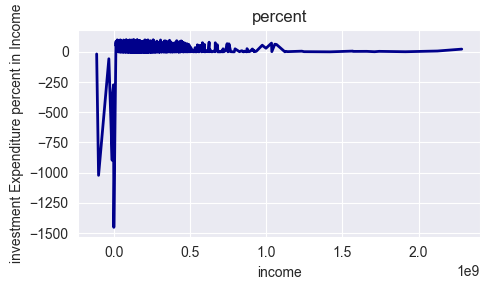

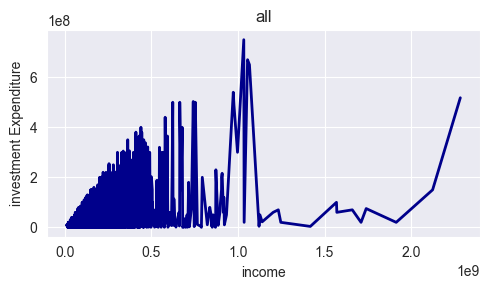

---------------1394---------------
---------------investment-----------------


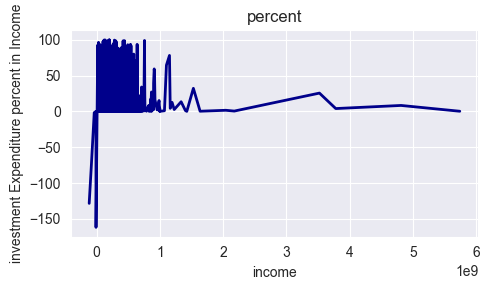

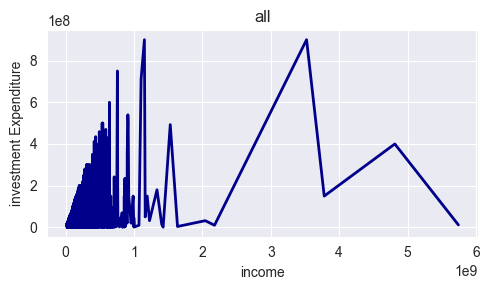

---------------1395---------------
---------------investment-----------------


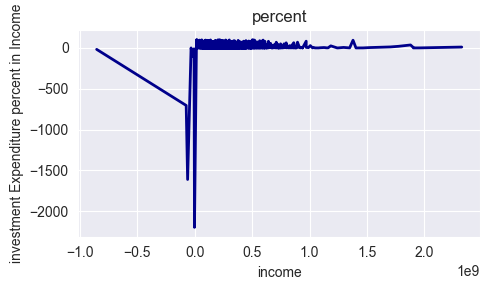

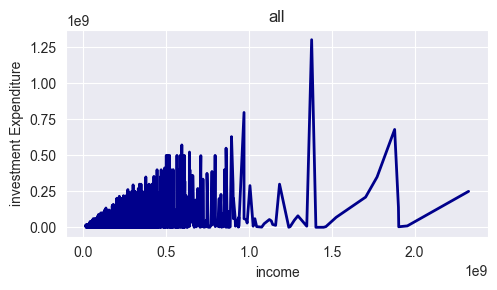

---------------1396---------------
---------------investment-----------------


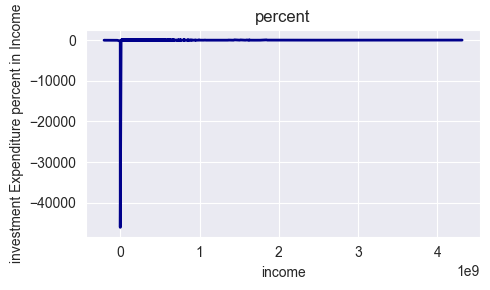

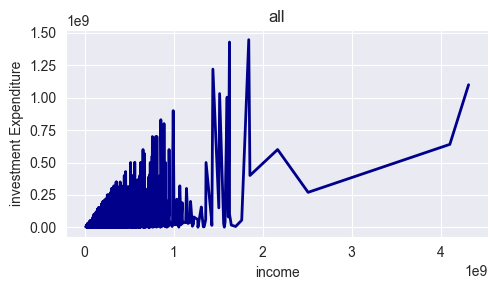

---------------1397---------------
---------------investment-----------------


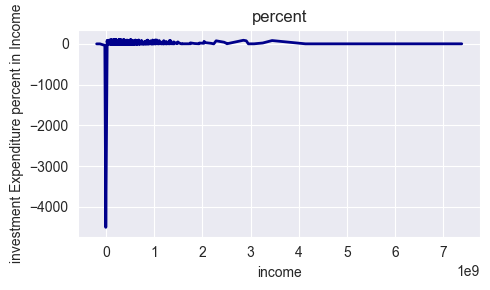

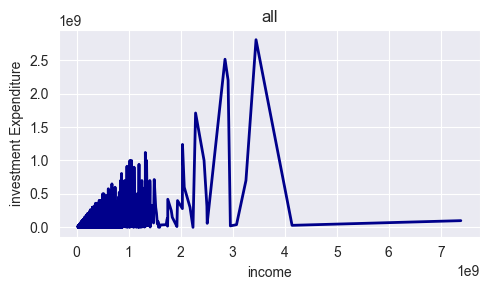

---------------1398---------------
---------------investment-----------------


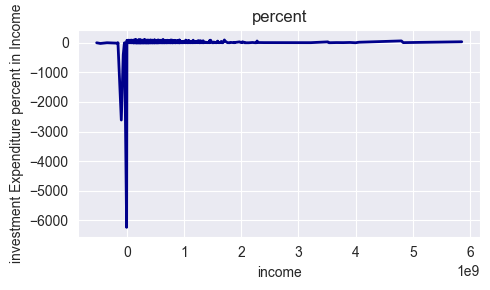

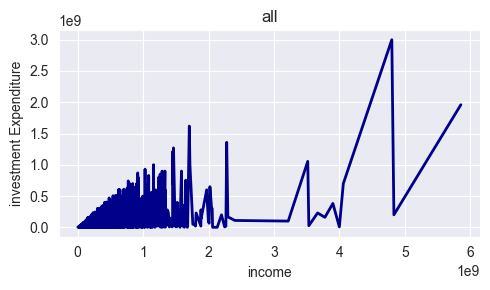

---------------1399---------------
---------------investment-----------------


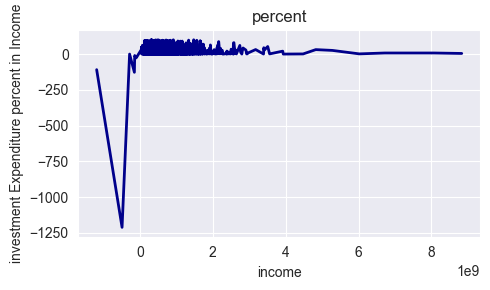

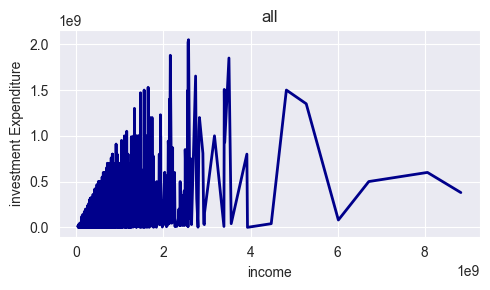

---------------1400---------------
---------------investment-----------------


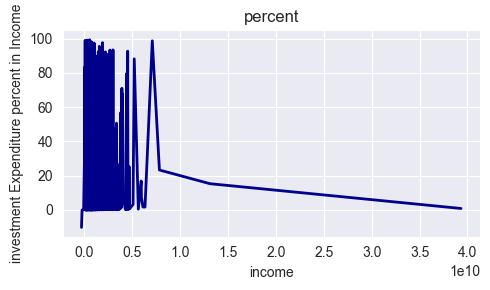

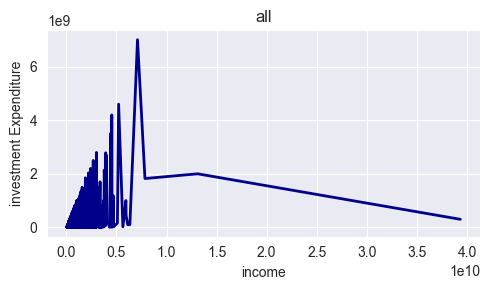

---------------1401---------------
---------------investment-----------------


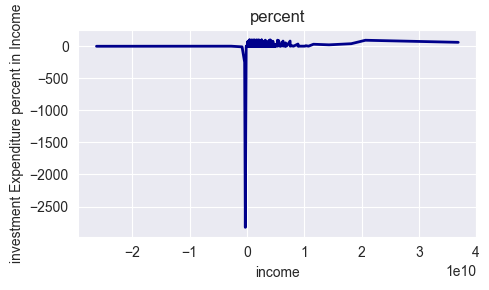

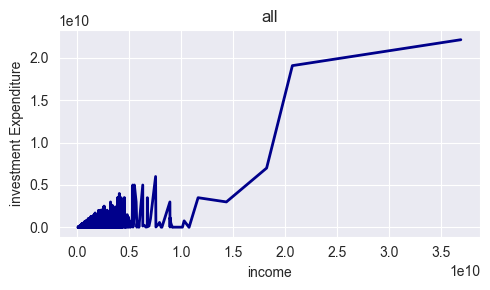

---------------1402---------------
---------------investment-----------------


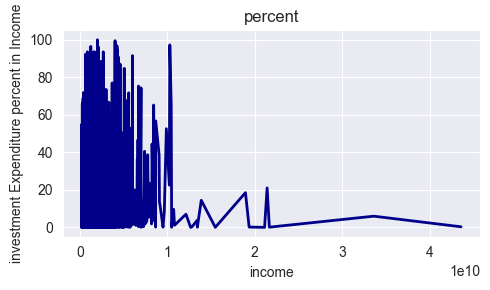

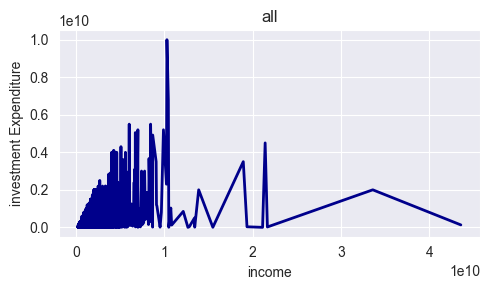

In [28]:
for year in range(1393, 1403):
    # year = 1394
    print(f"---------------{year}---------------")
    # food = csvfind("food", year)
    # Tobacco = csvfind("tobacco", year)
    # Cloth = csvfind("cloth", year)
    # Home = csvfind("home", year)
    # Furniture = csvfind("furniture", year)
    # Medical = csvfind("medical", year)
    # Transportation = csvfind("transportation", year)
    # Communication = csvfind("communication", year)
    # Entertainment = csvfind("entertainment", year)
    # # Education = csvfind("education",year)
    # Hotel = csvfind("hotel", year)
    # Miscellaneous = csvfind("miscellaneous", year)
    # Durable = csvfind("durable", year)
    Investment = csvfind("investment", year)
    employment_income = csvfind("employment_income", year)
    tables = [
        # food, Tobacco, Cloth, Home, Furniture, Medical, Transportation, Communication, Entertainment, Hotel,
        #       Miscellaneous, Durable,
        Investment]
    employment_income = get_total_income(year)
    # for table in tables:
    for table in tables:
        try:
            result = employment_income
            result.rename(columns={'Income': 'Monthly_Income'}, inplace=True)
            result['Monthly_Income'] = result['Monthly_Income']
            name = table['Table_Name'].loc[0]
            table['Expenditure'] = table['Expenditure'].fillna(0)
            table = table.groupby('ID').agg({'Expenditure': 'sum'}).reset_index()
            result = pd.merge(result, table, on="ID")
            result_main = result
            result_main = result_main[result_main['Expenditure'] < result_main['Monthly_Income']]
            result['Expenditure'] = result['Expenditure'] / result['Monthly_Income']
            result['Expenditure'] = result['Expenditure'] * 100
            result = result[result['Expenditure'] < 100]

        except Exception as e:
            print(f"<UNK> Error processing table {name}: {e}")
        print(f"---------------{name}-----------------")
        # for table in tables:
        result = result.groupby('Monthly_Income').agg({
            'Expenditure': 'mean'}).reset_index()
        plt.figure(figsize=(5, 3))
        plt.plot(result['Monthly_Income'], result['Expenditure'], color='darkblue', linewidth=2)
        plt.xlabel("income")
        plt.ylabel(f"{name} Expenditure percent in Income")
        plt.title("percent")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        result_main = result_main.groupby('Monthly_Income').agg({
            'Expenditure': 'mean'}).reset_index()
        plt.figure(figsize=(5, 3))
        plt.plot(result_main['Monthly_Income'], result_main['Expenditure'], color='darkblue', linewidth=2)
        plt.xlabel("income")
        plt.ylabel(f"{name} Expenditure")
        plt.title("all")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

eshteghal zanan va daramad

In [29]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

In [30]:
Members_Total_Income1400 = csvfind("Members_Total_Income", 1400)
members1400 = csvfind("members_properties", 1400)
members1400 = members1400[members1400['Sex'] == 'Male']
mergeMen = pd.merge(members1400, Members_Total_Income1400, on=['ID', 'Member_Number'])
mergeMen["Year"] = 1400
mergeMen = hbsir.add_attribute(table=mergeMen, name='Province', year_col="Year", id_col="ID")
mergeMen = hbsir.add_attribute(table=mergeMen, name="Urban_Rural", year_col="Year", id_col="ID")
mergeMen = hbsir.add_attribute(table=mergeMen, name="County", year_col="Year", id_col="ID")


In [31]:
Members_Total_Income1400 = csvfind("Members_Total_Income", 1400)
members1400 = csvfind("members_properties", 1400)
members1400 = members1400[members1400['Sex'] == 'Female']
mergeWoman = pd.merge(members1400, Members_Total_Income1400, on=['ID', 'Member_Number'])
mergeWoman["Year"] = 1400
mergeWoman = hbsir.add_attribute(table=mergeWoman, name='Province', year_col="Year", id_col="ID")
mergeWoman = hbsir.add_attribute(table=mergeWoman, name="Urban_Rural", year_col="Year", id_col="ID")
mergeWoman = hbsir.add_attribute(table=mergeWoman, name="County", year_col="Year", id_col="ID")


In [32]:
print(mergeWoman.head())

   Year_x           ID  Member_Number Relationship     Sex  Age Is_Literate  \
0    1400  20001384220              2       Spouse  Female   30        True   
1    1400  20013397029              2       Spouse  Female   47        True   
2    1400  20001384225              2       Spouse  Female   43        True   
3    1400  20001384232              2       Spouse  Female   35        True   
4    1400  20001384235              2       Spouse  Female   70       False   

  Is_Student  Education_Level Marital_Status Activity_Status  Year_y  \
0      False   Pre_University        Married     Housekeeper    1400   
1      False          Primary        Married     Housekeeper    1400   
2      False   Pre_University        Married     Housekeeper    1400   
3      False  Lower_Secondary        Married     Housekeeper    1400   
4        NaN              NaN        Married     Housekeeper    1400   

       Income  Year Province Urban_Rural   County  
0  10920000.0  1400  Markazi       Rural

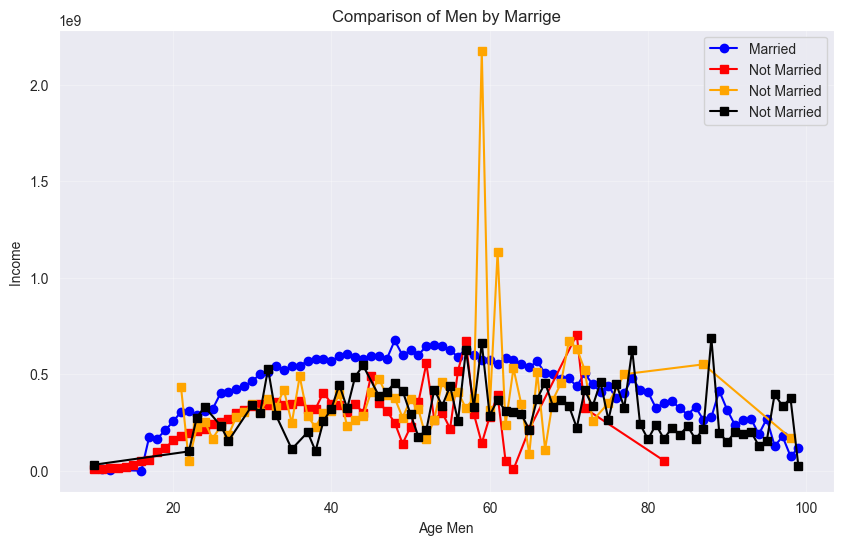

In [33]:
Married_man = mergeMen[mergeMen["Marital_Status"] == "Married"].groupby("Age")["Income"].mean().reset_index()
Bachelor_man = mergeMen[mergeMen["Marital_Status"] == "Bachelor"].groupby("Age")["Income"].mean().reset_index()
Divorced_man = mergeMen[mergeMen["Marital_Status"] == "Divorced"].groupby("Age")["Income"].mean().reset_index()
Widowed_man = mergeMen[mergeMen["Marital_Status"] == "Widowed"].groupby("Age")["Income"].mean().reset_index()

plt.figure(figsize=(10, 6))

plt.plot(Married_man["Age"], Married_man['Income'],
         label='Married', color='blue', marker='o', linestyle='-')

plt.plot(Bachelor_man['Age'], Bachelor_man['Income'],
         label='Not Married', color='red', marker='s', linestyle='-')

plt.plot(Divorced_man['Age'], Divorced_man['Income'],
         label='Not Married', color='orange', marker='s', linestyle='-')

plt.plot(Widowed_man['Age'], Widowed_man['Income'],
         label='Not Married', color='black', marker='s', linestyle='-')

plt.title('Comparison of Men by Marrige')
plt.xlabel('Age Men')
plt.ylabel('Income ')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

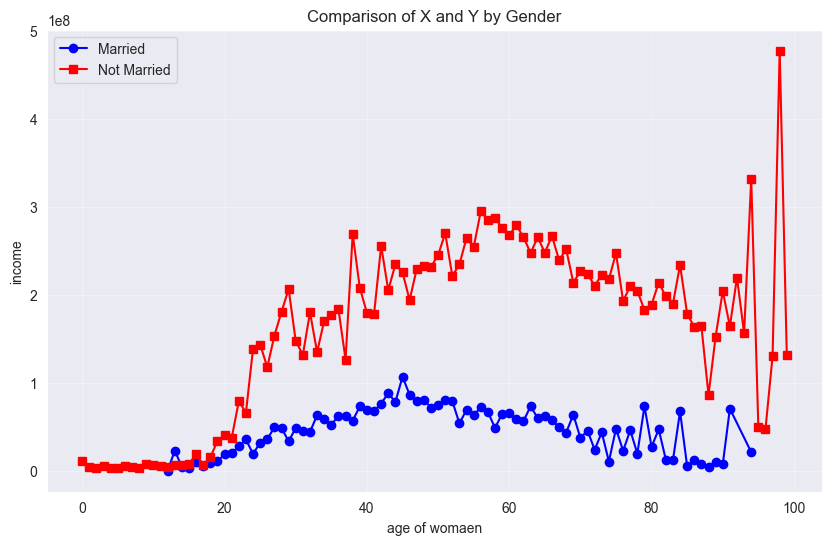

In [34]:
Rural_woman = mergeWoman[mergeWoman["Marital_Status"] == "Married"]
Urban_woman = mergeWoman[mergeWoman["Marital_Status"] != "Married"]
Rural_woman = Rural_woman.groupby("Age")["Income"].mean().reset_index()
Urban_woman = Urban_woman.groupby("Age")["Income"].mean().reset_index()

plt.figure(figsize=(10, 6))

plt.plot(Rural_woman["Age"], Rural_woman['Income'],
         label='Married', color='blue', marker='o', linestyle='-')

plt.plot(Urban_woman['Age'], Urban_woman['Income'],
         label='Not Married', color='red', marker='s', linestyle='-')

plt.title('Comparison of X and Y by Gender')
plt.xlabel('age of womaen')
plt.ylabel('income')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

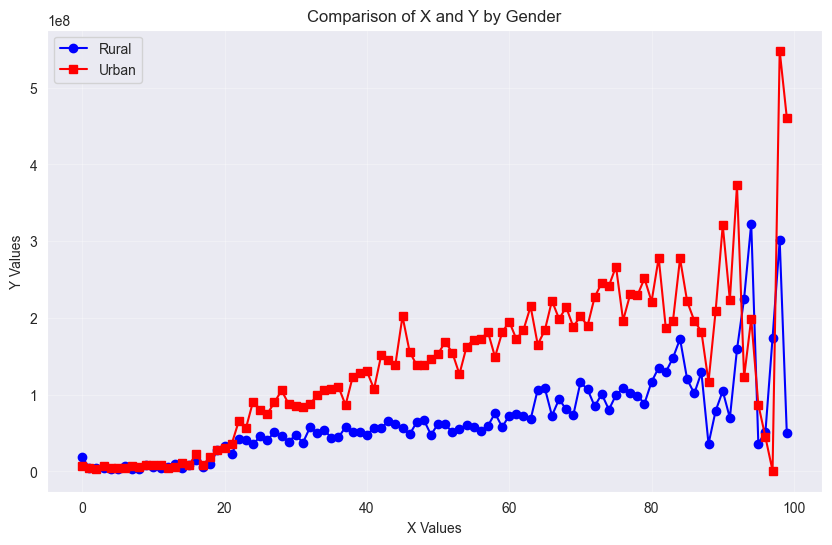

In [35]:
Rural_woman = mergeWoman[mergeWoman["Urban_Rural"] == "Rural"]
Urban_woman = mergeWoman[mergeWoman["Urban_Rural"] == "Urban"]
Rural_woman = Rural_woman.groupby("Age")["Income"].mean().reset_index()
Urban_woman = Urban_woman.groupby("Age")["Income"].mean().reset_index()

plt.figure(figsize=(10, 6))

plt.plot(Rural_woman["Age"], Rural_woman['Income'],
         label='Rural', color='blue', marker='o', linestyle='-')

plt.plot(Urban_woman['Age'], Urban_woman['Income'],
         label='Urban', color='red', marker='s', linestyle='-')

plt.title('Comparison of X and Y by Gender')
plt.xlabel('X Values')
plt.ylabel('Y Values')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

In [128]:
pay_gaps = []
time_range = []
means_income_women = []
medians_income_women = []
means_income_men = []
medians_income_men = []
FLFPRs = []
MLFPRs = []
Income_Recipiency_Rate_females = []
Income_Recipiency_Rate_males = []
numberOfWomanPerManforEmployd = []
for year in range(1393, 1403):
    Members_Total_Income = csvfind("Members_Total_Income", year)
    members = csvfind("members_properties", year)
    income_info = csvfind("employment_income", year)
    members["Year"] = year
    members = hbsir.add_attribute(table=members, name='Province', year_col="Year", id_col="ID")
    members = hbsir.add_attribute(table=members, name="Urban_Rural", year_col="Year", id_col="ID")
    members = hbsir.add_attribute(table=members, name="County", year_col="Year", id_col="ID")
    members = pd.merge(members, Members_Total_Income, on=['ID', 'Member_Number'])
    # members =  pd.merge(members, income_info, on=['ID','Member_Number'])

    # womenmembers = members[members['Sex'] == 'Female']
    # menmembers =  members[members['Sex'] == 'Male']
    members = members[members["Age"] >= 10]
    employed = members[members["Activity_Status"] == "Employed"]
    findjobs = members[(members["Activity_Status"] == "Employed") | (members["Activity_Status"] == "Unemployed")]
    haveIncome = members[
        (members["Activity_Status"] == "Employed") | (members["Activity_Status"] == "Income_without_Work")]
    numberOf_findjobs_woman = len(findjobs[findjobs['Sex'] == 'Female'])
    numberOf_all_woman = len(members[members['Sex'] == 'Female'])
    numberOf_haveIncome_woman = len(haveIncome[haveIncome['Sex'] == 'Female'])
    # Female Labor Force Participation Rate - FLFPR
    FLFPR = (numberOf_findjobs_woman / numberOf_all_woman) * 100
    # Income_Recipiency_Rate
    Income_Recipiency_Rate_female = (numberOf_haveIncome_woman / numberOf_all_woman) * 100
    # mean_income_women
    mean_income_women = employed[employed['Sex'] == 'Female']['Income'].mean()
    median_income_women = employed[employed['Sex'] == 'Female']['Income'].median()
    medians_income_women.append(median_income_women)
    numberOf_findjobs_man = len(findjobs[findjobs['Sex'] == 'Male'])
    numberOf_all_man = len(members[members['Sex'] == 'Male'])
    numberOf_haveIncome_man = len(haveIncome[haveIncome['Sex'] == 'Male'])
    # Male Labor Force Participation Rate - MLFPR
    MLFPR = (numberOf_findjobs_man / numberOf_all_man) * 100
    # Income_Recipiency_Rate
    Income_Recipiency_Rate_male = (numberOf_haveIncome_man / numberOf_all_man) * 100
    # mean_income_women
    mean_income_men = employed[employed['Sex'] == 'Male']['Income'].mean()
    median_income_men = employed[employed['Sex'] == 'Male']['Income'].median()
    medians_income_men.append(median_income_men)
    # pay_gap
    pay_gap = ((mean_income_men - mean_income_women) / mean_income_men) * 100
    numberOfWomanPerManforEmployd.append(100 * len(employed[employed['Sex'] == 'Female']) / len(employed[employed['Sex'] == 'Male']))

    # diff_employed = employed.dropna(subset=["Working_Hours_per_Day","Working_Day_per_Week"]).copy()
    # diff_employed["Working_Hours_per_Week"] = diff_employed["Working_Hours_per_Day"]* diff_employed["Working_Day_per_Week"]
    # diff_employed_men = diff_employed[diff_employed['Sex'] == 'Male']
    # diff_employed_women = diff_employed[diff_employed['Sex'] == 'Female']
    # diff_employed_men = diff_employed_men.groupby("Working_Hours_per_Week")["Income"].mean().reset_index()
    # diff_employed_women = diff_employed_women.groupby("Working_Hours_per_Week")["Income"].mean().reset_index()
    # print(f"****************************************** {year}****************************************** ")
    # plt.figure(figsize=(10, 6))
    #
    # plt.plot(diff_employed_men["Working_Hours_per_Week"], diff_employed_men['Income'],
    #          label='Rural', color='blue', marker='o', linestyle='-')
    #
    # plt.plot(diff_employed_women['Working_Hours_per_Week'], diff_employed_women['Income'],
    #          label='Urban', color='red', marker='s', linestyle='-')
    #
    # plt.title(f'Comparison of Working_Hours_per_Week and Income by Gender in {year}')
    # plt.xlabel('Working_Hours_per_Week')
    # plt.ylabel('Income')
    #
    # plt.legend()
    #
    # plt.grid(True, alpha=0.3)
    time_range.append(year)
    print(f"pay gap: {pay_gap:.2f} %")
    pay_gaps.append(pay_gap)
    print("_____________Female____________")
    print(f"mean_income_of_women : {mean_income_women:.0f} Rial")
    means_income_women.append(mean_income_women)
    print(f"Female Labor Force Participation Rate in {year} :{FLFPR:.2f}%")
    FLFPRs.append(FLFPR)
    print(f"Female_Income_Recipiency_Rate :{Income_Recipiency_Rate_female:.2f}%")
    Income_Recipiency_Rate_females.append(Income_Recipiency_Rate_female)
    print("_____________Male____________")
    print(f"mean_income_of_men : {mean_income_men:.0f} Rial")
    means_income_men.append(mean_income_men)
    print(f"Male Labor Force Participation Rate in {year} :{MLFPR:.2f}%")
    MLFPRs.append(MLFPR)
    print(f"Male_Income_Recipiency_Rate :{Income_Recipiency_Rate_male:.2f}%")
    Income_Recipiency_Rate_males.append(Income_Recipiency_Rate_male)

pay gap: 63.55 %
_____________Female____________
mean_income_of_women : 42307116 Rial
Female Labor Force Participation Rate in 1393 :44.75%
Female_Income_Recipiency_Rate :79.89%
_____________Male____________
mean_income_of_men : 116053688 Rial
Male Labor Force Participation Rate in 1393 :82.49%
Male_Income_Recipiency_Rate :94.18%
pay gap: 58.86 %
_____________Female____________
mean_income_of_women : 55121151 Rial
Female Labor Force Participation Rate in 1394 :42.36%
Female_Income_Recipiency_Rate :77.79%
_____________Male____________
mean_income_of_men : 133974393 Rial
Male Labor Force Participation Rate in 1394 :81.59%
Male_Income_Recipiency_Rate :93.39%
pay gap: 57.66 %
_____________Female____________
mean_income_of_women : 63383935 Rial
Female Labor Force Participation Rate in 1395 :41.62%
Female_Income_Recipiency_Rate :77.96%
_____________Male____________
mean_income_of_men : 149706993 Rial
Male Labor Force Participation Rate in 1395 :81.11%
Male_Income_Recipiency_Rate :93.34%
pay 

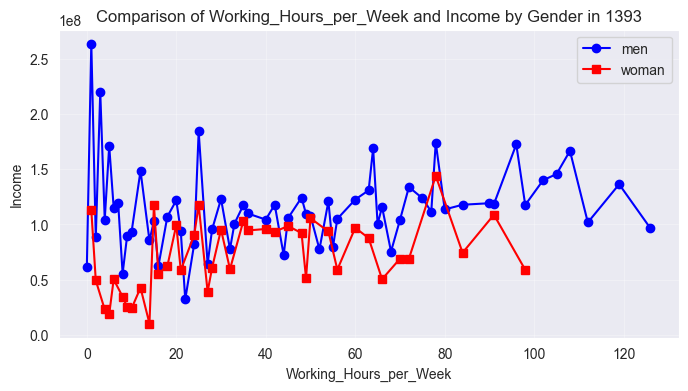

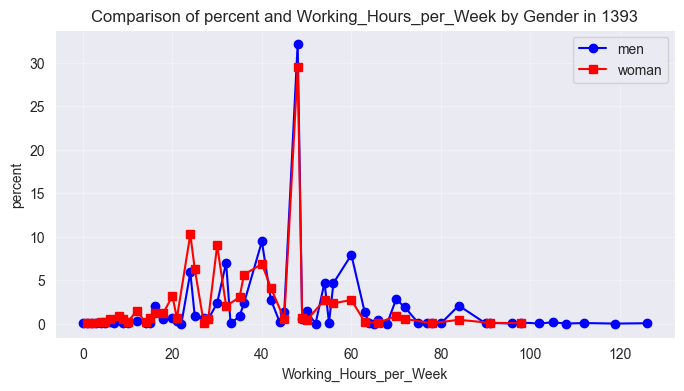

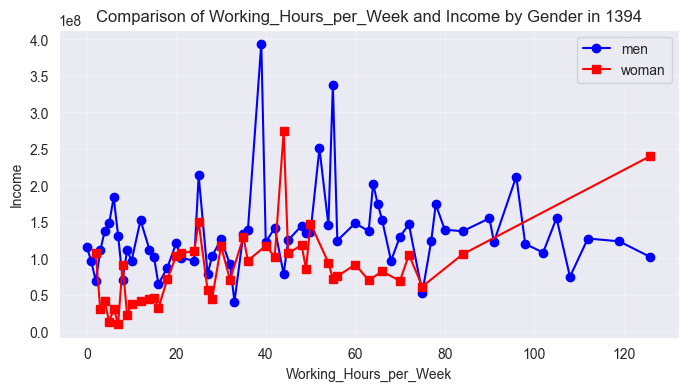

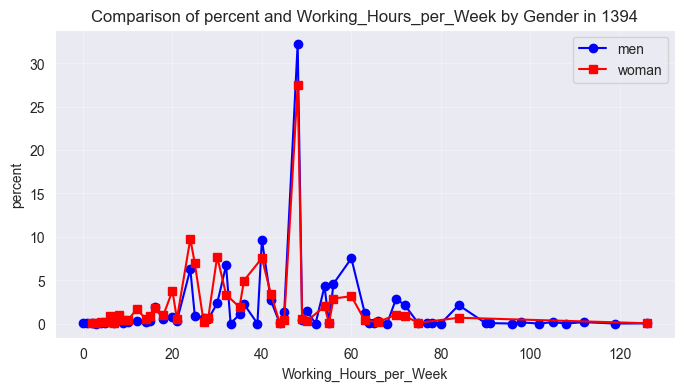

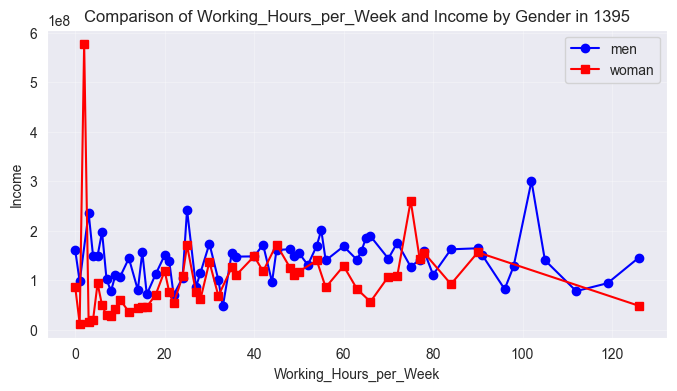

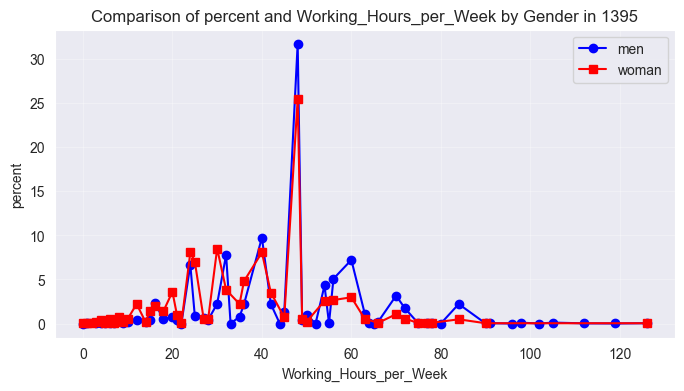

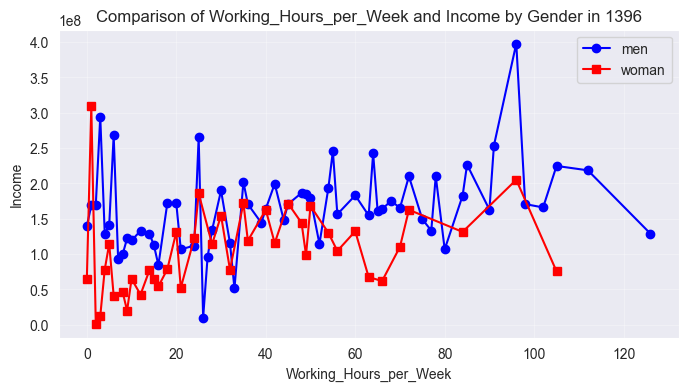

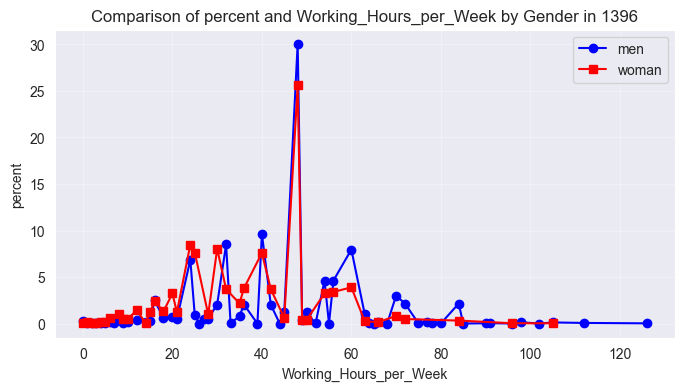

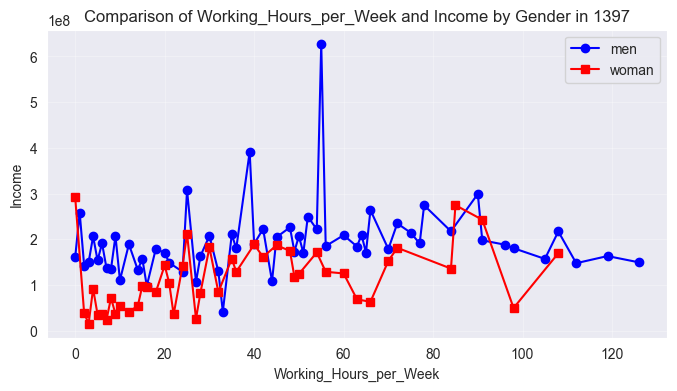

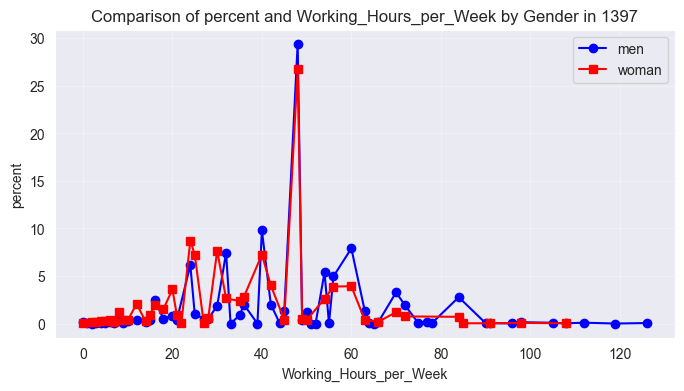

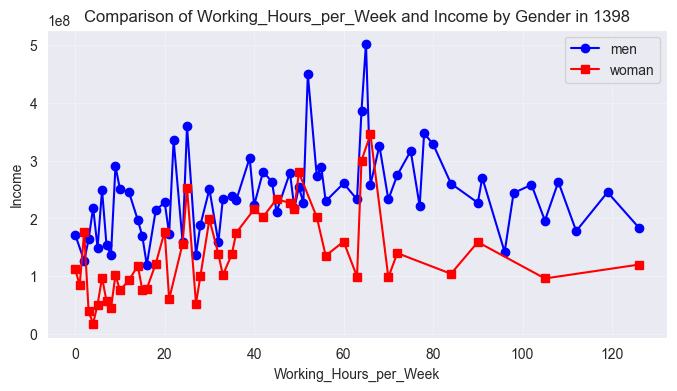

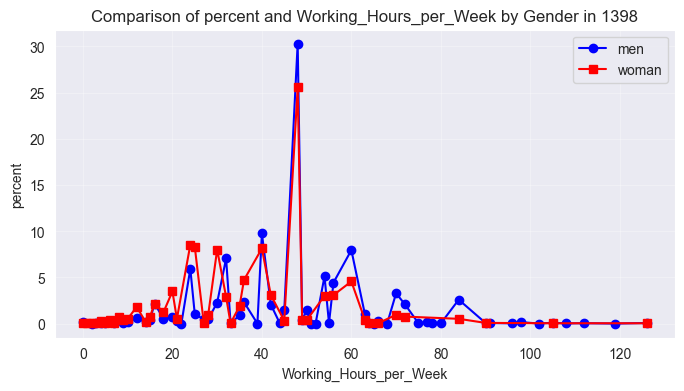

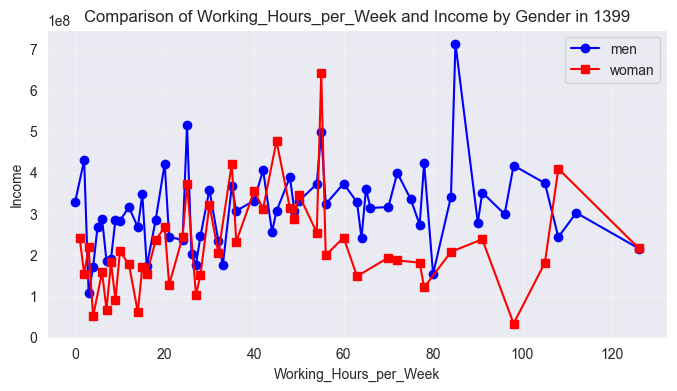

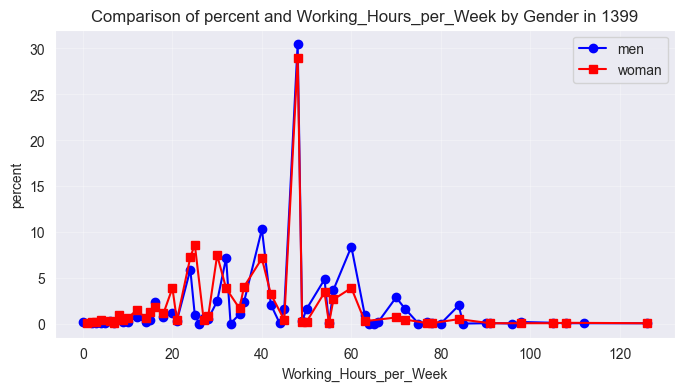

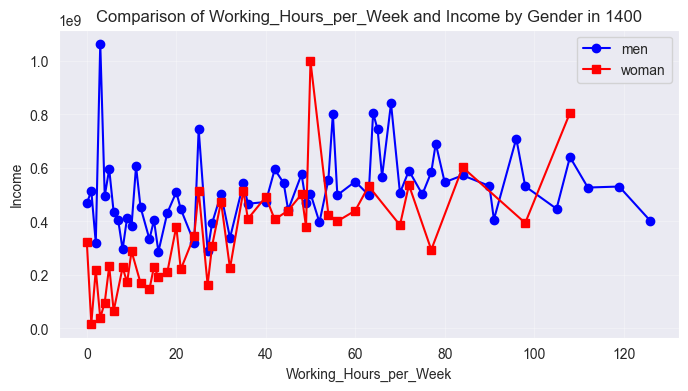

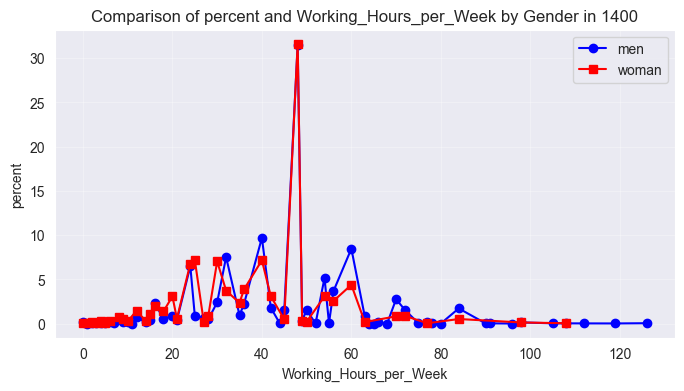

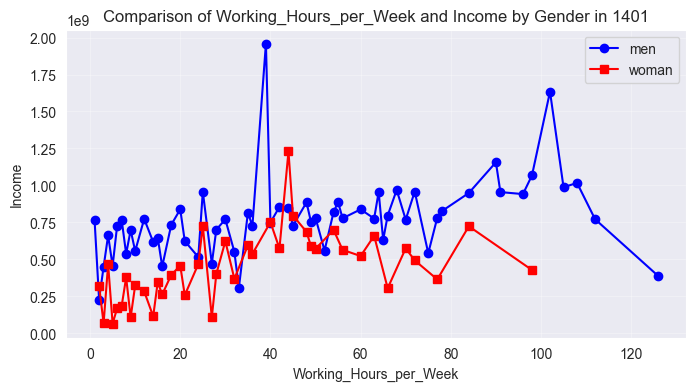

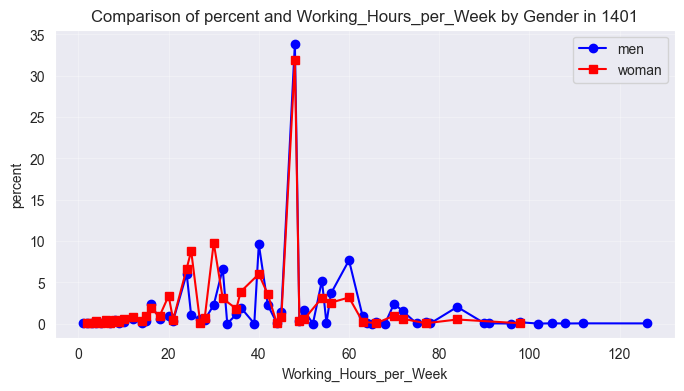

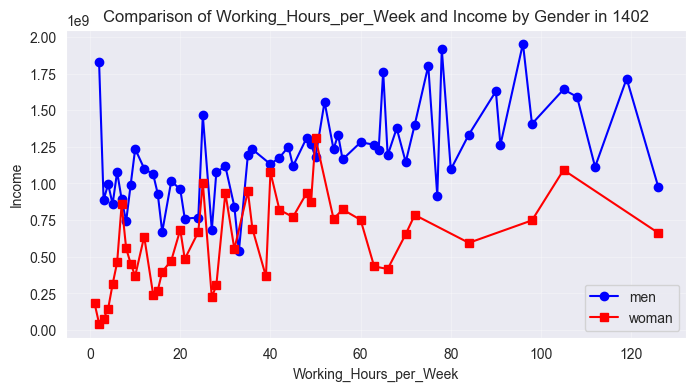

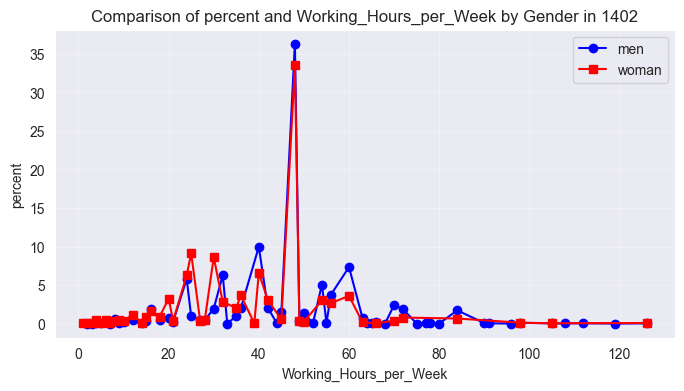

In [37]:
for year in range(1393, 1403):
    Members_Total_Income = csvfind("Members_Total_Income", year)
    members = csvfind("members_properties", year)
    income_info = csvfind("employment_income", year)
    info_income = pd.DataFrame()

    info_income[["Working_Hours_per_Day", "Working_Day_per_Week", 'ID', 'Member_Number']] = income_info[
        ["Working_Hours_per_Day", "Working_Day_per_Week", 'ID', 'Member_Number']]
    members["Year"] = year
    members = hbsir.add_attribute(table=members, name='Province', year_col="Year", id_col="ID")
    members = hbsir.add_attribute(table=members, name="Urban_Rural", year_col="Year", id_col="ID")
    members = hbsir.add_attribute(table=members, name="County", year_col="Year", id_col="ID")
    members = pd.merge(members, Members_Total_Income, on=['ID', 'Member_Number'])
    members = pd.merge(members, info_income, on=['ID', 'Member_Number'])

    members = members[members["Age"] >= 10]
    employed = members[members["Activity_Status"] == "Employed"]
    findjobs = members[(members["Activity_Status"] == "Employed") | (members["Activity_Status"] == "Unemployed")]
    haveIncome = members[
        (members["Activity_Status"] == "Employed") | (members["Activity_Status"] == "Income_without_Work")]
    numberOf_findjobs_woman = len(findjobs[findjobs['Sex'] == 'Female'])
    numberOf_all_woman = len(members[members['Sex'] == 'Female'])
    numberOf_haveIncome_woman = len(haveIncome[haveIncome['Sex'] == 'Female'])
    # Female Labor Force Participation Rate - FLFPR
    FLFPR = (numberOf_findjobs_woman / numberOf_all_woman) * 100
    # Income_Recipiency_Rate
    Income_Recipiency_Rate_female = (numberOf_haveIncome_woman / numberOf_all_woman) * 100
    # mean_income_women
    mean_income_women = employed[employed['Sex'] == 'Female']['Income'].mean()

    numberOf_findjobs_man = len(findjobs[findjobs['Sex'] == 'Male'])
    numberOf_all_man = len(members[members['Sex'] == 'Male'])
    numberOf_haveIncome_man = len(haveIncome[haveIncome['Sex'] == 'Male'])
    # Male Labor Force Participation Rate - MLFPR
    MLFPR = (numberOf_findjobs_man / numberOf_all_man) * 100
    # Income_Recipiency_Rate
    Income_Recipiency_Rate_male = (numberOf_haveIncome_man / numberOf_all_man) * 100
    # mean_income_women
    mean_income_men = employed[employed['Sex'] == 'Male']['Income'].mean()
    # pay_gap
    pay_gap = ((mean_income_men - mean_income_women) / mean_income_men) * 100

    diff_employed = employed.dropna(subset=["Working_Hours_per_Day", "Working_Day_per_Week"]).copy()
    diff_employed["Working_Hours_per_Week"] = diff_employed["Working_Hours_per_Day"] * diff_employed[
        "Working_Day_per_Week"]
    diff_employed_men = diff_employed[diff_employed['Sex'] == 'Male']
    diff_employed_women = diff_employed[diff_employed['Sex'] == 'Female']
    diff_employed_men = diff_employed_men.groupby("Working_Hours_per_Week")["Income"].mean().reset_index()
    diff_employed_women = diff_employed_women.groupby("Working_Hours_per_Week")["Income"].mean().reset_index()

    plt.figure(figsize=(8, 4))

    plt.plot(diff_employed_men["Working_Hours_per_Week"], diff_employed_men['Income'],
             label='men', color='blue', marker='o', linestyle='-')

    plt.plot(diff_employed_women['Working_Hours_per_Week'], diff_employed_women['Income'],
             label='woman', color='red', marker='s', linestyle='-')

    plt.title(f'Comparison of Working_Hours_per_Week and Income by Gender in {year}')
    plt.xlabel('Working_Hours_per_Week')
    plt.ylabel('Income')

    plt.legend()

    plt.grid(True, alpha=0.3)
    diff_employed["count"] = 1

    diff_count_men = diff_employed[diff_employed['Sex'] == 'Male'].groupby("Working_Hours_per_Week")[
        "count"].sum().reset_index()
    diff_count_women = diff_employed[diff_employed['Sex'] == 'Female'].groupby("Working_Hours_per_Week")[
        "count"].sum().reset_index()

    # plt.figure(figsize=(8, 4))
    #
    # plt.plot(diff_count_men["Working_Hours_per_Week"], diff_count_men['count'],
    #          label='men', color='blue', marker='o', linestyle='-')
    #
    # plt.plot(diff_count_women['Working_Hours_per_Week'], diff_count_women['count'],
    #          label='woman', color='red', marker='s', linestyle='-')
    #
    # plt.title(f'Comparison of count and Working_Hours_per_Week by Gender in {year}')
    # plt.xlabel('Working_Hours_per_Week')
    # plt.ylabel('count')
    #
    # plt.legend()
    #
    # plt.grid(True, alpha=0.3)

    all_count_men = len(diff_employed[diff_employed['Sex'] == 'Male'])
    all_count_women = len(diff_employed[diff_employed['Sex'] == 'Female'])
    diff_count_men['count'] = (diff_count_men['count'] / all_count_men) * 100
    diff_count_women['count'] = (diff_count_women['count'] / all_count_women) * 100
    plt.figure(figsize=(8, 4))

    plt.plot(diff_count_men["Working_Hours_per_Week"], diff_count_men['count'],
             label='men', color='blue', marker='o', linestyle='-')

    plt.plot(diff_count_women['Working_Hours_per_Week'], diff_count_women['count'],
             label='woman', color='red', marker='s', linestyle='-')

    plt.title(f'Comparison of percent and Working_Hours_per_Week by Gender in {year}')
    plt.xlabel('Working_Hours_per_Week')
    plt.ylabel('percent')

    plt.legend()

    plt.grid(True, alpha=0.3)

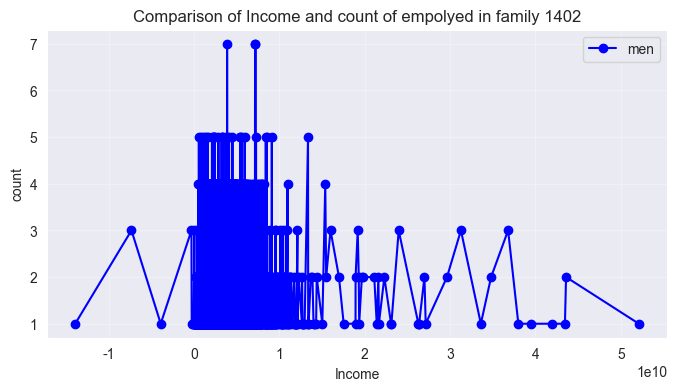

In [44]:
year = 1402
Total_Income = csvfind("Total_Income", year)
members = csvfind("members_properties", year)
members["count"] = 1

members["Year"] = year
members = hbsir.add_attribute(table=members, name='Province', year_col="Year", id_col="ID")
members = hbsir.add_attribute(table=members, name="Urban_Rural", year_col="Year", id_col="ID")
members = hbsir.add_attribute(table=members, name="County", year_col="Year", id_col="ID")

employed = members[members["Activity_Status"] == "Employed"]
employed_family = employed.groupby('ID').agg({
    'count': 'sum'}).reset_index()
employed_family = pd.merge(employed_family, Total_Income, on=['ID'])

employed_family = employed_family.dropna(subset=["Income"]).copy()

employed_family = employed_family.groupby('Income')["count"].mean().reset_index()

plt.figure(figsize=(8, 4))

plt.plot(employed_family["Income"], employed_family['count'],
         label='men', color='blue', marker='o', linestyle='-')

# plt.plot(diff_count_women['Working_Hours_per_Week'], diff_count_women['count'],
#          label='woman', color='red', marker='s', linestyle='-')

plt.title(f'Comparison of Income and count of empolyed in family {year}')
plt.xlabel('Income')
plt.ylabel('count')

plt.legend()

plt.grid(True, alpha=0.3)

In [ ]:
for year in range(1392, 1403):
    Total_Income = csvfind("Total_Income", year)
    members = csvfind("members_properties", year)
    members["count"] = 1

    members["Year"] = year
    members = hbsir.add_attribute(table=members, name='Province', year_col="Year", id_col="ID")
    members = hbsir.add_attribute(table=members, name="Urban_Rural", year_col="Year", id_col="ID")
    members = hbsir.add_attribute(table=members, name="County", year_col="Year", id_col="ID")

    employed = members[members["Activity_Status"] == "Employed"]
    employed_family = employed.groupby('ID').agg({
        'count': 'sum'}).reset_index()
    employed_family = pd.merge(employed_family, Total_Income, on=['ID'])

    employed_family = employed_family.dropna(subset=["Income"]).copy()

    employed_family = employed_family.groupby('Income')["count"].mean().reset_index()
    max_income = employed_family["Income"].max()
    min_income = employed_family["Income"].min()
    median_income =employed_family["Income"].median()
    mx_med = max_income/median_income
    bins =[min_income]
    labels =[]
    n =int( mx_med)
    for i in range(n) :
        bins.append((i/n) * max_income)
        labels.append(str(i/n))

    result = (employed_family.groupby(pd.cut(employed_family['Income'],
                                             bins=bins,
                                             labels=labels,
                                             right=False))
              ['count'].mean()
              .reset_index()
              .rename(columns={'index': 'Income_Range'}))
    plt.figure(figsize=(12, 4))

    plt.plot(result["Income"], result['count'],
             label='men', color='blue', marker='o', linestyle='-')

    plt.title(f'Comparison of Income and count of empolyed in family {year}')
    plt.xlabel('Income')
    plt.ylabel('count')

    plt.legend()

    plt.grid(True, alpha=0.3)

In [ ]:
for year in range(1392, 1403):
    Total_Income = csvfind("Total_Income", year)
    members = csvfind("members_properties", year)
    members["count"] = 1

    members["Year"] = year
    members = hbsir.add_attribute(table=members, name='Province', year_col="Year", id_col="ID")
    members = hbsir.add_attribute(table=members, name="Urban_Rural", year_col="Year", id_col="ID")
    members = hbsir.add_attribute(table=members, name="County", year_col="Year", id_col="ID")

    employed = members[members["Activity_Status"] == "Employed"]
    employed_family = employed.groupby('ID').agg({
        'count': 'sum'}).reset_index()
    employed_family = pd.merge(employed_family, Total_Income, on=['ID'])

    employed_family = employed_family.dropna(subset=["Income"]).copy()

    employed_family = employed_family.groupby('Income')["count"].mean().reset_index()
    max_income = employed_family["Income"].max()
    min_income = employed_family["Income"].min()
    median_income = employed_family["Income"].median()
    mx_med = max_income/median_income
    bins = [min_income]
    labels = []
    n = int(mx_med)
    for i in range(n):
        bins.append((i/n) * max_income)
        labels.append(str(i/n))

    # گروه‌بندی داده‌ها
    result = (employed_family.groupby(pd.cut(employed_family['Income'],
                                             bins=bins,
                                             labels=labels,
                                             right=False))
              ['count'].mean()
              .reset_index()
              .rename(columns={'index': 'Income_Range'}))

    # پردازش bins خالی
    result['count'] = result['count'].fillna(0)  # جایگزینی مقادیر NaN با صفر

    # شناسایی نقاط اصلی و نقاط اضافه شده
    original_points = result['count'].copy()
    corrected_counts = result['count'].copy()
    interpolated_points = []  # لیست برای شناسایی نقاط اضافه شده

    # بررسی bins خالی و جایگزینی با میانگین bin قبل و بعد
    for i in range(len(corrected_counts)):
        if corrected_counts[i] == 0:  # اگر bin خالی باشد
            prev_value = None
            next_value = None

            # پیدا کردن مقدار bin قبل (غیر صفر)
            for j in range(i-1, -1, -1):
                if corrected_counts[j] != 0:
                    prev_value = corrected_counts[j]
                    break

            # پیدا کردن مقدار bin بعد (غیر صفر)
            for j in range(i+1, len(corrected_counts)):
                if corrected_counts[j] != 0:
                    next_value = corrected_counts[j]
                    break

            # محاسبه میانگین اگر هر دو مقدار موجود باشند
            if prev_value is not None and next_value is not None:
                corrected_counts[i] = (prev_value + next_value) / 2
                interpolated_points.append(i)  # اضافه کردن اندیس نقطه اضافه شده
            elif prev_value is not None:  # اگر فقط مقدار قبل موجود باشد
                corrected_counts[i] = prev_value
                interpolated_points.append(i)
            elif next_value is not None:  # اگر فقط مقدار بعد موجود باشد
                corrected_counts[i] = next_value
                interpolated_points.append(i)
            # اگر هیچکدام موجود نباشد، صفر باقی می‌ماند

    # جایگزینی ستون count با مقادیر اصلاح شده
    result['count_corrected'] = corrected_counts

    plt.figure(figsize=(12, 6))

    # جدا کردن نقاط اصلی و نقاط اضافه شده
    original_indices = [i for i in range(len(result)) if i not in interpolated_points]
    interpolated_indices = interpolated_points

    # رسم خط اصلی (همه نقاط)
    plt.plot(result["Income"], result['count_corrected'],
             color='blue', linestyle='-', linewidth=2, label='Trend line')

    # رسم نقاط اصلی با مارکر دایره آبی
    if original_indices:
        plt.scatter(result.iloc[original_indices]["Income"],
                   result.iloc[original_indices]['count_corrected'],
                   color='blue', marker='o', s=60, label='Original data', zorder=5)

    # رسم نقاط اضافه شده با مارکر متفاوت
    if interpolated_indices:
        plt.scatter(result.iloc[interpolated_indices]["Income"],
                   result.iloc[interpolated_indices]['count_corrected'],
                   color='red', marker='s', s=60, label='Interpolated points', zorder=5)

    # یا روش دوم: رسم نقاط اضافه شده با مارکر ستاره
    # if interpolated_indices:
    #     plt.scatter(result.iloc[interpolated_indices]["Income"],
    #                result.iloc[interpolated_indices]['count_corrected'],
    #                color='orange', marker='*', s=100, label='Interpolated points', zorder=5)

    plt.title(f'Comparison of Income and count of employed in family {year}\n(Red squares show interpolated points)')
    plt.xlabel('Income')
    plt.ylabel('Count')

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



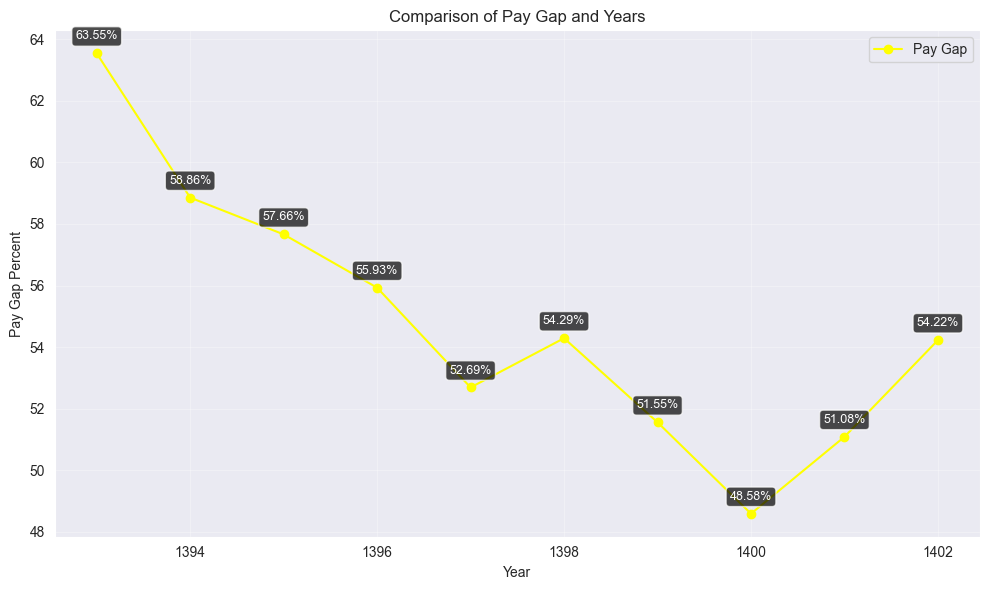

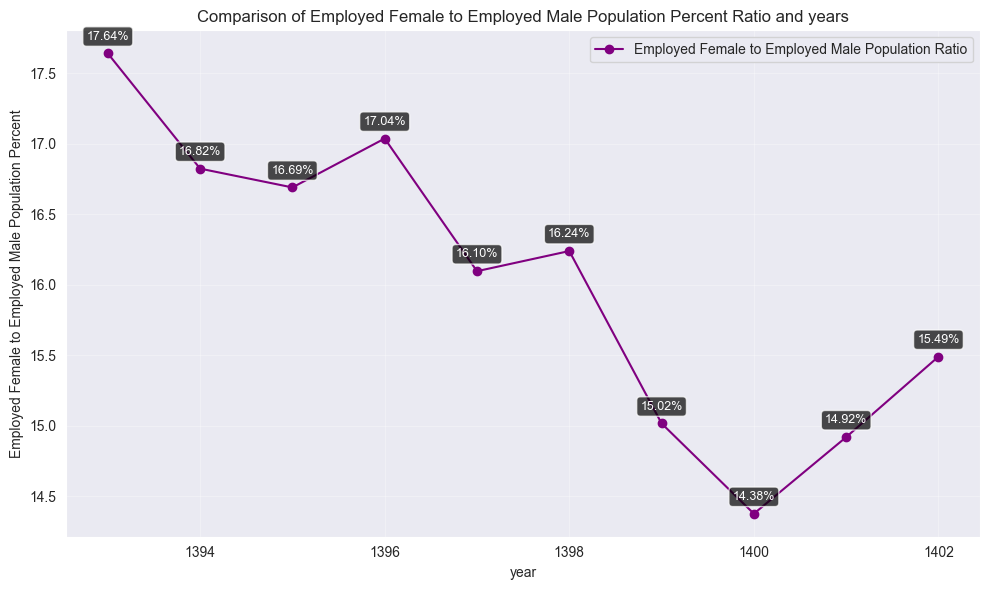

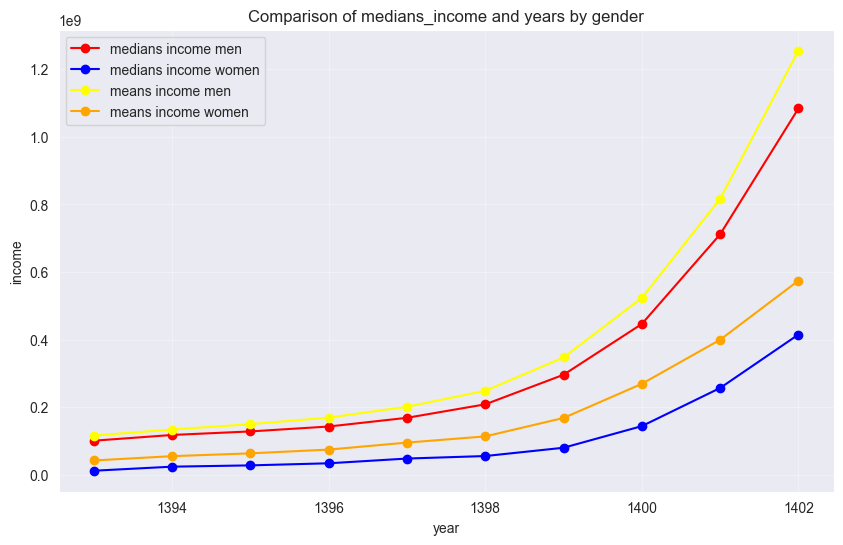

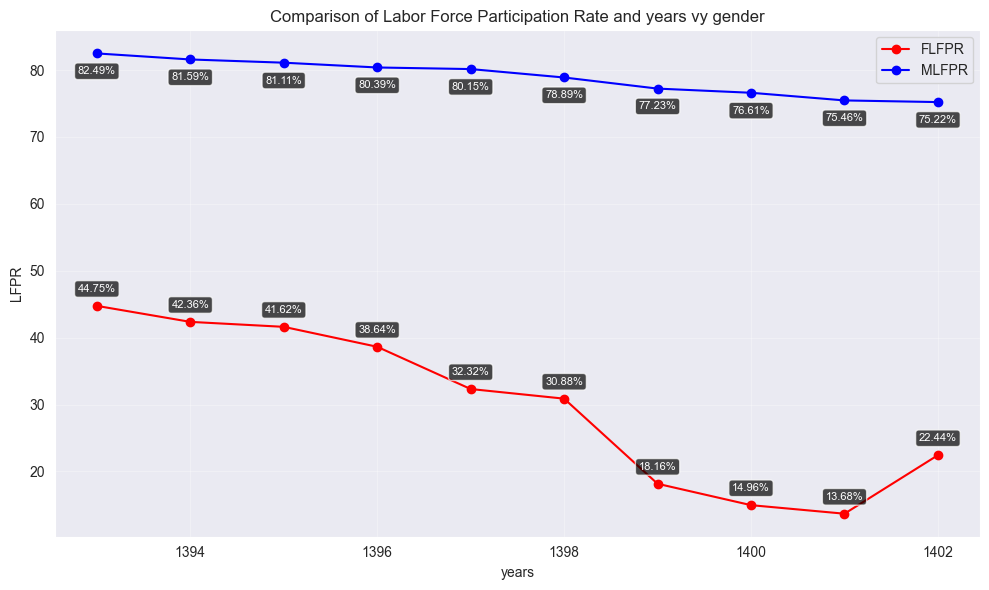

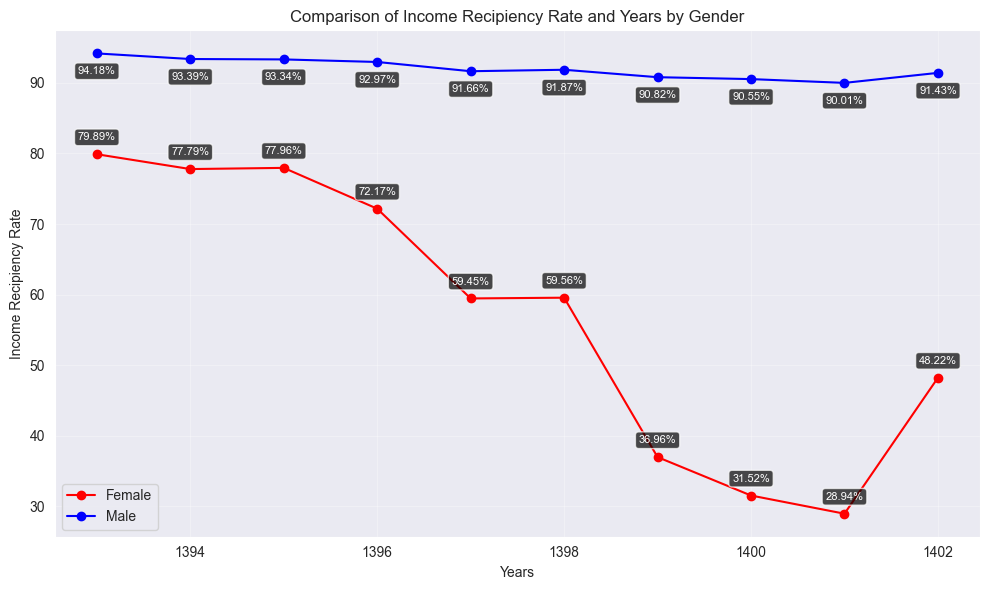

In [138]:
# pay_gaps =[]
# time_range =[]
# means_income_women =[]
# medians_income_women =[]
# means_income_men =[]
# medians_income_men =[]
# FLFPRs =[]
# MLFPRs = []
# Income_Recipiency_Rate_females =[]
# Income_Recipiency_Rate_males =[]
# numberOfWomanPerManforEmployd
plt.figure(figsize=(10, 6))
plt.plot(time_range, pay_gaps, label='Pay Gap', color='yellow', marker='o', linestyle='-')
plt.title('Comparison of Pay Gap and Years')
plt.xlabel('Year')
plt.ylabel('Pay Gap Percent')

# اضافه کردن مقادیر روی نقاط
for i, (x, y) in enumerate(zip(time_range, pay_gaps)):
    plt.annotate(f'{y:.2f}%',  # نمایش با دو رقم اعشار
                 (x, y),
                 textcoords="offset points",
                 xytext=(0, 10),  # فاصله متن از نقطه
                 ha='center',     # تراز وسط
                 fontsize=9,
                 color='white',   # رنگ متن
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))  # پس‌زمینه مشکی

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(time_range, numberOfWomanPerManforEmployd,
         label='Employed Female to Employed Male Population Ratio', color='purple', marker='o', linestyle='-')
plt.title(f'Comparison of Employed Female to Employed Male Population Percent Ratio and years')
plt.xlabel('year')
plt.ylabel('Employed Female to Employed Male Population Percent')
for i, (x, y) in enumerate(zip(time_range, numberOfWomanPerManforEmployd)):
    plt.annotate(f'{y:.2f}%',  # نمایش با دو رقم اعشار
                 (x, y),
                 textcoords="offset points",
                 xytext=(0, 10),  # فاصله متن از نقطه
                 ha='center',     # تراز وسط
                 fontsize=9,
                 color='white',   # رنگ متن
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))  # پس‌زمینه مشکی
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))
plt.plot(time_range, medians_income_men,
         label='medians income men', color='red', marker='o', linestyle='-')
plt.plot(time_range, medians_income_women,
         label='medians income women', color='blue', marker='o', linestyle='-')
plt.plot(time_range, means_income_men,
         label='means income men', color='yellow', marker='o', linestyle='-')
plt.plot(time_range, means_income_women,
         label='means income women', color='orange', marker='o', linestyle='-')
plt.title(f'Comparison of medians_income and years by gender')
plt.xlabel('year')
plt.ylabel('income')

plt.legend()

plt.grid(True, alpha=0.3)

plt.figure(figsize=(10, 6))
plt.plot(time_range, FLFPRs,
         label='FLFPR', color='red', marker='o', linestyle='-')
plt.plot(time_range, MLFPRs,
         label='MLFPR', color='blue', marker='o', linestyle='-')
plt.title(f'Comparison of Labor Force Participation Rate and years vy gender')
plt.xlabel('years')
plt.ylabel('LFPR')
for i, (x, y) in enumerate(zip(time_range, FLFPRs)):
    plt.annotate(f'{y:.2f}%',
                 (x, y),
                 textcoords="offset points",
                 xytext=(0, 10),  # فاصله از نقطه
                 ha='center',
                 fontsize=8,
                 color='white',   # رنگ متن
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))  # پس‌زمینه مشکی

# اضافه کردن مقادیر برای مردان
for i, (x, y) in enumerate(zip(time_range, MLFPRs)):
    plt.annotate(f'{y:.2f}%',
                 (x, y),
                 textcoords="offset points",
                 xytext=(0, -15),  # فاصله از نقطه (پایین)
                 ha='center',
                 fontsize=8,
                 color='white',   # رنگ متن
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))  # پس‌زمینه مشکی

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(time_range, Income_Recipiency_Rate_females,
         label='Female', color='red', marker='o', linestyle='-')
plt.plot(time_range, Income_Recipiency_Rate_males,
         label='Male', color='blue', marker='o', linestyle='-')

plt.title('Comparison of Income Recipiency Rate and Years by Gender')
plt.xlabel('Years')
plt.ylabel('Income Recipiency Rate')

# اضافه کردن مقادیر برای زنان
for i, (x, y) in enumerate(zip(time_range, Income_Recipiency_Rate_females)):
    plt.annotate(f'{y:.2f}%',
                 (x, y),
                 textcoords="offset points",
                 xytext=(0, 10),  # فاصله از نقطه
                 ha='center',
                 fontsize=8,
                 color='white',   # رنگ متن
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))  # پس‌زمینه مشکی

# اضافه کردن مقادیر برای مردان
for i, (x, y) in enumerate(zip(time_range, Income_Recipiency_Rate_males)):
    plt.annotate(f'{y:.2f}%',
                 (x, y),
                 textcoords="offset points",
                 xytext=(0, -15),  # فاصله از نقطه (پایین)
                 ha='center',
                 fontsize=8,
                 color='white',   # رنگ متن
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))  # پس‌زمینه مشکی

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
